<a href="https://colab.research.google.com/github/anshikacomputes/Bio-Signal-Peak-Detection/blob/main/Bio-Signal-Peak-Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

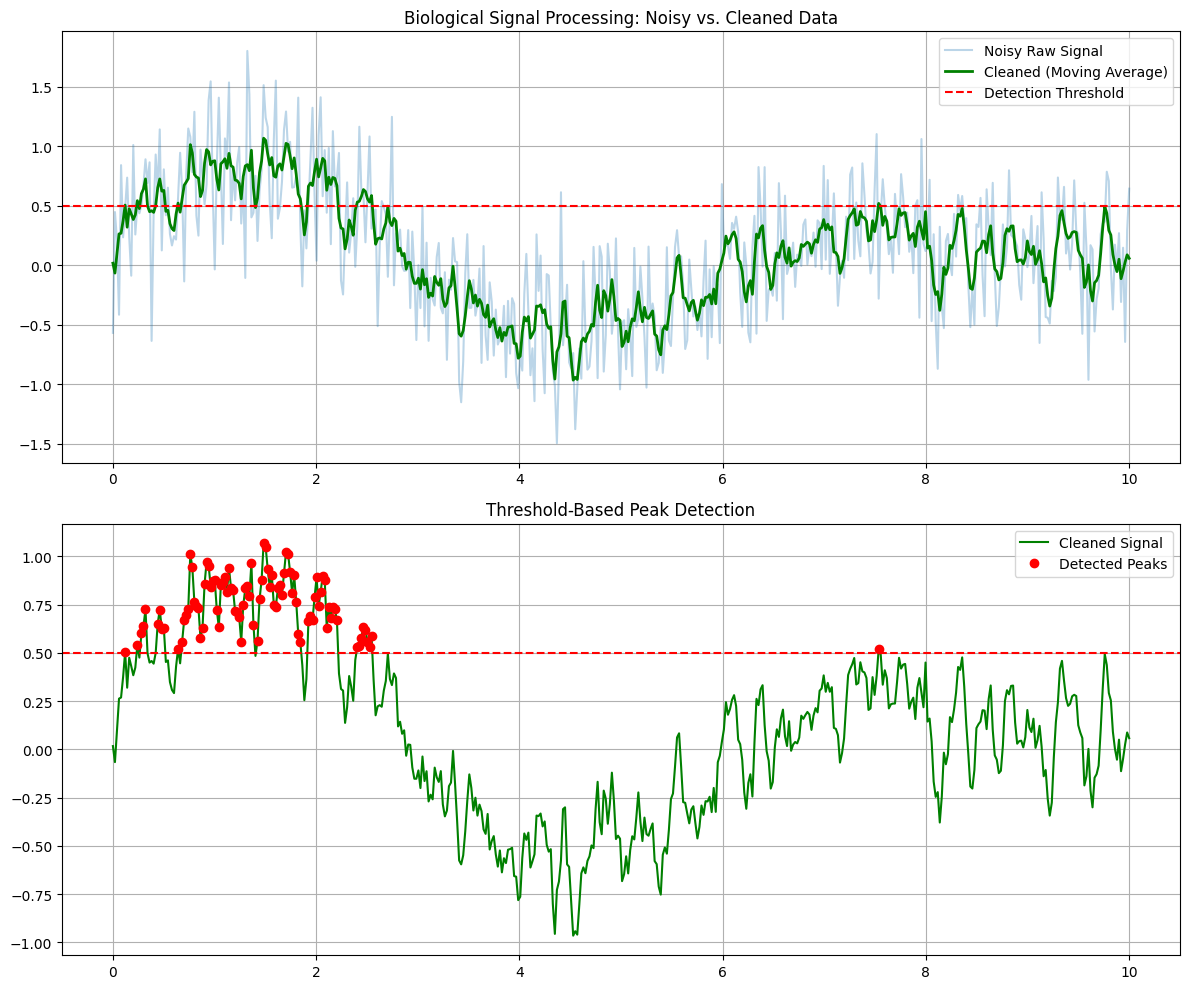

In [13]:
# =========================================================================
# Project 3: Biological Signal Peak Detection Pipeline
# Author: Anshika (BSc Zoology)
# GitHub: github.com/anshikacomputes/Bio-Signal-Peak-Detection
#
# Purpose: This project simulates a noisy biological signal (e.g., EEG/EKG)
# and demonstrates threshold-based peak detection. This is the critical
# first step before applying advanced neural models.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# Step 1: Simulate a Noisy Biological Signal
# =========================================================================
# Create a smooth base signal (representing true data)
t = np.linspace(0, 10, 500)
base_signal = np.sin(t) * (1 - t/10) # Declining sine wave

# Add massive high-frequency noise (representing interference)
noise = np.random.normal(0, 0.4, 500)
noisy_signal = base_signal + noise

# =========================================================================
# Step 2: Signal Filtering (A "Technical" Lesson)
# We apply a 5-point 'Moving Average' filter. A key skill in signal processing.
# =========================================================================
window_size = 5
cleaned_signal = np.convolve(noisy_signal, np.ones(window_size)/window_size, mode='same')

# =========================================================================
# Step 3: Threshold-Based Peak Detection
# We will flag any signal points above a simple threshold as potential 'peaks'
# (representing events like a heartbeat or seizure).
# =========================================================================
threshold = 0.5
detected_peaks = np.where(cleaned_signal > threshold)[0]

# =========================================================================
# Step 4: Multi-Panel Visualization
# Multi-panel plots look very advanced and scientific.
# =========================================================================
plt.figure(figsize=(12, 10))

# Subplot 1: Noisy vs Clean
plt.subplot(2, 1, 1)
plt.plot(t, noisy_signal, label='Noisy Raw Signal', alpha=0.3)
plt.plot(t, cleaned_signal, label='Cleaned (Moving Average)', color='green', linewidth=2)
plt.axhline(y=threshold, color='red', linestyle='--', label='Detection Threshold')
plt.title('Biological Signal Processing: Noisy vs. Cleaned Data')
plt.legend()
plt.grid(True)

# Subplot 2: Detected Peaks
plt.subplot(2, 1, 2)
plt.plot(t, cleaned_signal, color='green', label='Cleaned Signal')
# 'ro' plots red 'o' (dots) where peaks are detected.
plt.plot(t[detected_peaks], cleaned_signal[detected_peaks], 'ro', label='Detected Peaks')
plt.axhline(y=threshold, color='red', linestyle='--')
plt.title('Threshold-Based Peak Detection')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()